In [ ]:
import numpy as np
import pandas as pd
import pyvista as pv
import matplotlib.pyplot as plt
from tqdm import tqdm
from pathlib import Path
import json

from phd_helpers.paths import get_task_stl_paths, get_mesh, avg_edge_length, get_info, get_subject_stl_path
from phd_helpers.MeshQuality import (
        compute_d_metrics, compute_dists, compute_mesh_metrics, compute_rmsd, sample_surface
    )

# Why remesh?
 - Want to arrive at converged height field
 - But computational complexity increases exponentially with n points
     - so only increasing density of cartilage area saves computation time
     - and also results in more evenly distributed points so maximises coverage of height field for given number of points.
     - it is also necesarry for cartilage generation step as cartilage is extruded around taper region which requires evenly spaced points to work reliably.
        - not isotropic mesh can result in intersecting or inverted faces.

Could just take one example mesh and do subdvides and measure time to compute height field
then compare that to the time to compute the height field with only partial remesh

## How dense and how many iterations?
 - First find FEL to establish n points needed for height field convergence 
    - choose fel based on convergence and runtime
 - Then run that height field for different iteration counts and show no change - might be though due to smoothing
     - so scrap that and just do them independently 
 -  Choose iterations based on change in fine region of bone and runtime
     - mention that cgal says more iterations tends to result in smoother surface and closer match to target edge length
     - so need to be wary of excess extra smoothing.
 
 - fels = [0.6, 0.424, 0.3, 0.212, 0.15, 0.106]
     - start at 0.6 everywhere as this is close to the largest average edge length in the dataset
     - then refine cartilage region to see what affect this has on the height field
     - then choose refinement that gives good runtime or % change in max distance
 - iterations = [1, 5, 10, 20, 40, 80]

#### Redo clean run of bone mesh generation
 - only include subs_ok (based on smoothed meshes (also remeshed meshes))
 - only ran for tpm
    -  run again just below for mc1

In [ ]:
import subprocess
path_MeshPipeline_main = '../../../../MeshPipeline/main.py'
subprocess.run(["python", path_MeshPipeline_main])


Updating parameters.json
	Wrote /Users/maro/Library/CloudStorage/OneDrive-UniversityofLeeds/PhD-wrist/WorkPackages/WorkPackages/TMCJ-Contact/Computational/MeshPipeline/set_parameters/parameters.json


Full parameter file saved to outputs-redo/height_field/params/full_params.json

SUBJECT: 14548R
	BONES: tpm-mc1
		STEP: 2Dmesh
			RUN ID: -0
			Runtime: 4.808s - ok
			RUN ID: -1
			Runtime: 4.763s - ok
			RUN ID: -2
			Runtime: 4.873s - ok
			RUN ID: -3
			Runtime: 4.877s - ok
			RUN ID: -4
			Runtime: 5.089s - ok
			RUN ID: -5
			Runtime: 5.302s - ok
		STEP: cartilage
			RUN ID: -0-0
			Runtime: 1.779s - ok
			RUN ID: -1-0
			Runtime: 1.974s - ok
			RUN ID: -2-0
			Runtime: 2.319s - ok
			RUN ID: -3-0
			Runtime: 3.730s - ok
			RUN ID: -4-0
			Runtime: 6.031s - ok
			RUN ID: -5-0
			Runtime: 14.411s - ok

SUBJECT: 14613R
	BONES: tpm-mc1
		STEP: 2Dmesh
			RUN ID: -0
			Runtime: 4.780s - ok
			RUN ID: -1
			Runtime: 4.833s - ok
			RUN ID: -2
			Runtime: 4.871s - ok
			RUN ID: -3
			Runti

CompletedProcess(args=['python', '../../../../MeshPipeline/main.py'], returncode=0)

#### Re-run to get mc1 cartilage runtime

In [19]:
import subprocess
path_MeshPipeline_main = '../../../../MeshPipeline/main.py'
subprocess.run(["python", path_MeshPipeline_main])


Updating parameters.json
	Wrote /Users/maro/Library/CloudStorage/OneDrive-UniversityofLeeds/PhD-wrist/WorkPackages/WorkPackages/TMCJ-Contact/Computational/MeshPipeline/set_parameters/parameters.json


Full parameter file saved to outputs-redo/height_field/params/full_params-1.json

SUBJECT: 14548R
	BONES: mc1-tpm
		STEP: 2Dmesh
			RUN ID: -0
			Runtime: 1.616s - ok
			RUN ID: -1
			Runtime: 1.626s - ok
			RUN ID: -2
			Runtime: 1.562s - ok
			RUN ID: -3
			Runtime: 1.604s - ok
			RUN ID: -4
			Runtime: 1.577s - ok
			RUN ID: -5
			Runtime: 1.645s - ok
		STEP: cartilage
			RUN ID: -0-0
			Runtime: 2.284s - ok
			RUN ID: -1-0
			Runtime: 2.560s - ok
			RUN ID: -2-0
			Runtime: 3.118s - ok
			RUN ID: -3-0
			Runtime: 4.772s - ok
			RUN ID: -4-0
			Runtime: 7.469s - ok
			RUN ID: -5-0
			Runtime: 15.623s - ok

SUBJECT: 14613R
	BONES: mc1-tpm
		STEP: 2Dmesh
			RUN ID: -0
			Runtime: 1.733s - ok
			RUN ID: -1
			Runtime: 1.569s - ok
			RUN ID: -2
			Runtime: 1.648s - ok
			RUN ID: -3
			Run

CompletedProcess(args=['python', '../../../../MeshPipeline/main.py'], returncode=0)

### Generate Field meshes
 - use code directly from cartilage generation
 - only measure distance for inner region because of problems with delaunay at the edges where mesh folds round plus only inner region matters

In [2]:
from phd_helpers.CartilageGeneration import get_min_df_fast, get_triangle_adjacency, flood_fill_cells, taper_f, interp_vecs
from phd_helpers.paths import get_boundary
from scipy.spatial.distance import cdist
import gdist

def generate_height_field(min_df, bone_mesh, taper_width):

    ################# MESH STUFF #################
    bone_mesh['Normals'] = bone_mesh.compute_normals(point_normals=True, cell_normals=False)['Normals']
    bone_mesh['bone_id'] = np.arange(bone_mesh.n_points)
    bone_mesh['bone_cell_id'] = np.arange(bone_mesh.n_cells)
    ################# MESH STUFF #################


    ################# COMPUTE TAPER REGION #################
    # extract mesh of cartilage points on bone mesh (makes gdist computation faster) - (bone-cartilage interface mesh)
    inter_mesh1 = bone_mesh.extract_points(min_df['bone_id'], adjacent_cells=False).extract_surface(algorithm=None)

    # JUST REMOVE ANY ISLANDS
    conn = inter_mesh1.connectivity(label_regions=True)
    region_ids = conn.cell_data["RegionId"]
    island_ids, counts = np.unique(region_ids, return_counts=True)
    largest_region_id = island_ids[np.argmax(counts)]
    inter_mesh = inter_mesh1.extract_cells(np.where(region_ids == largest_region_id)[0]).extract_surface(algorithm=None)
    inter_mesh['inter_cell_ids'] = np.arange(inter_mesh.n_cells)

    # remove any missing points due to extract geometry (incomplete triangles) and islands
    missing_mask = ~np.isin(min_df['bone_id'], inter_mesh['bone_id'])
    min_df.drop(min_df['bone_id'][missing_mask].index.values, inplace=True)

    # useful values from min_df (min_df does not change after this point - final change was at min_df.drop(missing))
    midpoint_dist = min_df['dist'] / 2 # distance of midpoint between two bones for each pair of closest points
    midpoints = np.array(min_df['midpoint'].tolist()) # midpoint coordinates
    #ar_points = np.array(min_df['ar_point'].tolist()) # closest points on ar bone to each bone point


    # get boundary of cartilage on inter mesh
    inter_boundary = get_boundary(inter_mesh)
    boundary_mask_inter = np.isin(inter_mesh['bone_id'], inter_boundary['bone_id']) 
    boundary_ids = np.arange(inter_mesh.n_points)[boundary_mask_inter] # on inter_mesh

    # minimum geo dist of every node from closest source_idx
    geo_dists = gdist.compute_gdist(
        inter_mesh.points.astype(np.float64),
        inter_mesh.faces.reshape(-1, 4)[:, 1:].astype(np.int32),
        source_indices=boundary_ids.astype(np.int32), 
    ) 

    # get mask of nodes within taper width and below taper function
    #taper_heights = taper_f(geo_dists, taper_width, max_height, p=p_h)
    #taper_mask = (taper_heights <= min_df['dist'] / 2) & (geo_dists<=taper_width)
    taper_mask = geo_dists<=taper_width # new

    # get taper points mesh (makes computation much faster) - mesh of only taper region
    taper_mask_inter = np.isin(inter_mesh['bone_id'], min_df['bone_id'][taper_mask])
    taper_mesh = inter_mesh.extract_points(taper_mask_inter, adjacent_cells=False).extract_surface(algorithm=None)
        # assign non-taper cells that lie on "pinched" islands to taper region
    not_taper_mesh = inter_mesh.extract_cells(taper_mesh['inter_cell_ids'], invert=True).extract_surface(algorithm=None)
    _, adjacency = get_triangle_adjacency(not_taper_mesh)
    start_face = not_taper_mesh.find_closest_cell(np.mean(not_taper_mesh.points, axis=0)) # not best way of doing this!
    inner_cells = flood_fill_cells(not_taper_mesh, start_face, get_boundary(not_taper_mesh).lines.reshape(-1, 3)[:, 1:], adjacency)
        # final taper mesh #
    taper_mesh = inter_mesh.extract_cells(not_taper_mesh['inter_cell_ids'][inner_cells], invert=True).extract_surface(algorithm=None)
    taper_mesh['taper_point_id'] = np.arange(taper_mesh.n_points)
        # remove any missing points from taper_mask after extracting geometry and islands - not ideal but quicker than using inter mesh
    taper_mask = np.isin(min_df['bone_id'], taper_mesh['bone_id'])
    #taper_geo_dists = geo_dists[taper_mask]

    # get taper mesh boundaries
    taper_boundary = get_boundary(taper_mesh)
    boundary_outer_mask_tb = np.isin(taper_boundary['bone_id'], inter_boundary['bone_id']) # on taper_boundary

    # get taper boundary innner and outer nodes on taper mesh
    taper_outer_ids = np.sort(taper_boundary['taper_point_id'][boundary_outer_mask_tb]) # on taper mesh
    taper_inner_ids = np.sort(taper_boundary['taper_point_id'][~boundary_outer_mask_tb]) # on taper mesh

    # ids and distances of boundary nodes that are closest to each taper node
    d_taper_outer = cdist(taper_mesh.points, taper_mesh.points[taper_outer_ids])
    near_taper_outer_D = d_taper_outer.min(axis=1)
    #near_taper_outer_ids = taper_outer_ids[np.argmin(d_taper_outer, axis=1)]

    d_taper_inner = cdist(taper_mesh.points, taper_mesh.points[taper_inner_ids])
    near_taper_inner_D = d_taper_inner.min(axis=1)
    near_taper_inner_ids = taper_inner_ids[np.argmin(d_taper_inner, axis=1)]

    # Distance fraction of each taper_mesh point from closest outer_node to closest_inner node
    taper_Df = (near_taper_outer_D) / (near_taper_outer_D + near_taper_inner_D)

    # get nearest inner node midpoint heights
    taper_inner_mask_c = np.isin(min_df['bone_id'], taper_mesh['bone_id'][taper_inner_ids]) # on c_mesh
    inner_node_midpoint_heights = midpoint_dist.values[taper_inner_mask_c]
    near_inner_node_midpoint_heights = inner_node_midpoint_heights[np.searchsorted(taper_inner_ids, near_taper_inner_ids)]

    # set taper node heights - should be based on interpolated height really - but as long as mesh is dense this is fine...
    taper_heights = taper_f(taper_Df, 1, near_inner_node_midpoint_heights, p=8.5) # non-linear

    # set vector directions
    midpoint_vecs = midpoints - bone_mesh.points[min_df['bone_id']] # vector from bone point to midpoint
    taper_vecs_mid = midpoint_vecs[taper_mask] # midpoint_vecs
    taper_vecs_norm = bone_mesh['Normals'][min_df['bone_id']][taper_mask] # normal vecs
    vec_dirs = taper_f(taper_Df, 1, 1, p=1)
    taper_vecs = interp_vecs(taper_vecs_norm, taper_vecs_mid, vec_dirs)

    # get taper coords
    taper_points = bone_mesh.points[min_df['bone_id']][taper_mask]
    taper_points = taper_points + taper_heights.reshape(-1, 1)*taper_vecs

    # get taper points
    points_tapered = midpoints.copy()
    points_tapered[taper_mask] = taper_points

    #closest_points, distances, cell_ids = get_trimesh(bone_mesh).nearest.on_surface(points_tapered)
    ################# COMPUTE TAPER REGION #################

    ################# MESH TAPER REGION #################
    # map faces from bone mesh to extruded taper region points
    # mesh curves down in taper region and delaunay doesn't like that
    tapered_mesh = pv.PolyData(taper_points, taper_mesh.faces)
    ################# MESH TAPER REGION #################

    ################# MESH INNER REGION #################
    tapered_edge = get_boundary(tapered_mesh)

    inner_edge = tapered_edge.extract_points(~boundary_outer_mask_tb).extract_surface(algorithm=None)
    #inner_points = pv.PolyData(midpoints[~taper_mask])
    inner_mesh = pv.PolyData(np.vstack( (inner_edge.points, midpoints[~taper_mask]) ), lines=inner_edge.lines)

    # alpha for coarse meshes wants to be slightly lower and vice versa - I think
    inner_mesh = inner_mesh.delaunay_2d(edge_source=inner_edge, alpha=0.9).triangulate()
    inner_mesh = inner_mesh.fill_holes(inner_mesh.area/20)
    #inner_mesh.lines = inner_edge.lines # reset edge lines to remove delaunay leftover lines
    inner_mesh.lines = np.empty(0, dtype='int64') # remove all lines for now cos they show up in mesh.faces

    # remove cells that lie outside of the inner region boundary
    _, adjacency = get_triangle_adjacency(inner_mesh)
    #start_face = inner_mesh.find_closest_cell(np.mean(inner_mesh.points, axis=0))
    start_face = inner_mesh.find_closest_cell(inner_mesh.center) # new 28/03/26
    inner_cells = flood_fill_cells(inner_mesh, start_face, inner_edge.lines.reshape(-1, 3)[:, 1:], adjacency)
    inner_mesh_clean = pv.PolyData(inner_mesh.points, inner_mesh.faces.reshape(-1, 4)[inner_cells])
    # should maybe be calling remove unused points here, lines bring their own points that are left behind?
    ################# MESH INNER REGION #################

    return inner_mesh_clean, inter_mesh

In [3]:
# paths & params
subs_ok = pd.read_csv('../../../../MeshPipeline/subs_ok.csv')['subs_ok'].to_numpy() # only subs with no interference

output_root = Path('outputs-redo/height_field')
param_path = output_root / 'params/full_params.json'
with open(param_path, 'r') as f:
    params = json.load(f)

bones = ['tpm', 'mc1']
fels = params['2Dmesh']['fine_edge_length']
smooth_iters = params['2Dmesh']['taubin_iters']
poses = ['adduction','abduction','flexion','extension','pinch','grasp','jar','neutral']

print('        Edge lengths:', fels)
print('Smoothing iterations:', smooth_iters)




        Edge lengths: [0.6, 0.424, 0.3, 0.212, 0.15, 0.106]
Smoothing iterations: 50


#### Save all field meshes and interface meshes

In [13]:
field_path = Path('outputs-redo/height_field_surfs')
field_path.mkdir(exist_ok=True)
for sub in tqdm(subs_ok):
    subject, sideL = sub[:-1], sub[-1]
    stl_path = get_subject_stl_path(subject, sideL)

    for i in range(len(fels)):
        run_id = f'-{i}'
        bone_remesh = pv.read(f'{output_root}/meshes/{sub}/{bones[0]}-{bones[1]}/2Dmesh/bone_remesh{run_id}.obj')
        arbone_remesh = pv.read(f'{output_root}/meshes/{sub}/{bones[1]}-{bones[0]}/2Dmesh/bone_remesh{run_id}.obj')

        for (bone, arbone), (bone_mesh, arbone_mesh) in zip(
                                                    [ [bones[0], bones[1]], [bones[1], bones[0]] ],
                                                    [ [bone_remesh, arbone_remesh], [arbone_remesh, bone_remesh] ]
                                                    ):
            min_df = get_min_df_fast(stl_path, bone, arbone, bone_mesh, arbone_mesh, poses)
            field_mesh, inter_mesh = (generate_height_field(min_df, bone_mesh, taper_width=1.5))

            inter_mesh.save(field_path / f'inter_{subject}{sideL}-{bone}-{i}.obj')
            field_mesh.save(field_path / f'field_{subject}{sideL}-{bone}-{i}.obj')


            

100%|██████████| 36/36 [33:14<00:00, 55.39s/it]


#### Compute metrics
 - Take uniform sample of points from each surface to be compared then measure combined distance metrics 
 - Sampling 20000 points gives a sampling density of roughly 100 points per mm^2 for the tpm-mc1 cartilage region of an average size (2000mm^3) trapezium
    - trust 

In [14]:
n_samples = 20000
bone_pairs = ['tpm-mc1', 'mc1-tpm']
field_path = Path('outputs-redo/height_field_surfs')

data = []
for sub in tqdm(subs_ok):
    subject, sideL = sub[:-1], sub[-1]
    stl_path = get_subject_stl_path(subject, sideL)
    for pair in bone_pairs:
        bone, arbone = pair.split('-')[0], pair.split('-')[-1]

        bone_smooth = get_mesh(stl_path, bone).smooth_taubin(n_iter=smooth_iters)
        field_fine = pv.read(field_path / f'field_{subject}{sideL}-{bone}-{len(fels)-1}.obj')
        for i, fel in enumerate(fels):  
            # get surfs
            field = pv.read(field_path / f'field_{subject}{sideL}-{bone}-{i}.obj')
            inter_remesh = pv.read(field_path / f'inter_{subject}{sideL}-{bone}-{i}.obj') # refined interface mesh of remeshed bone
            bone_remesh = pv.read(f'{output_root}/meshes/{sub}/{pair}/2Dmesh/bone_remesh-{i}.obj')
            # region of smooth mesh corresponding to inter (2mm) mesh - entirely contained within 2.5mm refined region
            inter_smooth = bone_smooth.extract_cells(np.unique(bone_smooth.find_closest_cell(inter_remesh.points))).extract_surface(algorithm=None)

            # bone to bone - based on interface mesh patch distance to full bone for both 
            d_remesh2smooth = compute_dists(sample_surface(inter_remesh, n_samples), bone_smooth)
            d_smooth2remesh = compute_dists(sample_surface(inter_smooth, n_samples), bone_remesh)
            d_b2b = np.hstack( (d_remesh2smooth, d_smooth2remesh) )
            # field to remesh
            d_f2b = compute_dists(sample_surface(field, n_samples), inter_remesh)

            mets = {
                'sub': f'{sub}',
                'bone': bone,
                'fel': fel,
                'b2b_rmsd': compute_rmsd(d_b2b),
                'f2b_rmsd': compute_rmsd(d_f2b),
            }

            # field to field fine
            if fel != fels[-1]:
                d_f2fine = compute_dists(sample_surface(field,      n_samples), field_fine) 
                d_fine2f = compute_dists(sample_surface(field_fine, n_samples), field) 
                d_f2f = np.hstack( (d_f2fine, d_fine2f) )

                mets['f2f_rmsd'] = compute_rmsd(d_f2f)
                mets = compute_d_metrics(d_f2f, mets, 'f2f_d_')

            # distance
            mets = compute_d_metrics(d_b2b, mets, 'b2b_d_')
            mets = compute_d_metrics(d_f2b, mets, 'f2b_d_')
            # curve?
            # surface
            mets = compute_mesh_metrics(field, mets, vol=False, edge_length=False, label='field_')
            mets = compute_mesh_metrics(bone_smooth, mets, vol=True, edge_length=False, label='smooth_')
            mets = compute_mesh_metrics(bone_remesh, mets, vol=True, edge_length=False, label='remesh_')


            data.append(mets)
pd.DataFrame(data).to_csv('outputs-redo/heightFieldMetrics-redo.csv', index=False)
        

100%|██████████| 36/36 [03:21<00:00,  5.60s/it]


In [59]:
df = pd.read_csv('outputs-redo/heightFieldMetrics-redo.csv')
df

,sub,bone,fel,b2b_rmsd,f2b_rmsd,f2f_rmsd,f2f_d_mean,f2f_d_median,f2f_d_std,f2f_d_max,...,field_cells,field_A,smooth_points,smooth_cells,smooth_A,smooth_V,remesh_points,remesh_cells,remesh_A,remesh_V
0,14548R,tpm,0.600,0.008510,0.460939,0.035511,0.010313,0.004288,0.033980,0.678337,...,615,77.315544,8454,16904,752.453625,1435.787027,2967,5930,748.498646,1431.862236
1,14548R,tpm,0.424,0.004365,0.461884,0.012823,0.004354,0.002100,0.012062,0.231986,...,1317,79.182260,8454,16904,752.453625,1435.787027,4198,8392,749.073735,1432.858230
2,14548R,tpm,0.300,0.002398,0.461803,0.008207,0.002635,0.001186,0.007772,0.192761,...,2327,79.718515,8454,16904,752.453625,1435.787027,5897,11790,749.404945,1433.332999
3,14548R,tpm,0.212,0.001515,0.461518,0.004337,0.001319,0.000602,0.004131,0.122721,...,5333,80.058022,8454,16904,752.453625,1435.787027,10108,20212,749.516087,1433.520443
4,14548R,tpm,0.150,0.000901,0.462856,0.002892,0.000891,0.000406,0.002752,0.098512,...,9310,80.682629,8454,16904,752.453625,1435.787027,15813,31622,749.650855,1433.627849
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
427,50053R,mc1,0.424,0.004282,0.481264,0.010726,0.003150,0.001286,0.010253,0.267087,...,2173,130.381109,27074,54144,2462.738825,6759.565639,11306,22608,2457.112865,6752.453367
428,50053R,mc1,0.300,0.002490,0.482900,0.007830,0.002061,0.000823,0.007554,0.193459,...,3924,131.355974,27074,54144,2462.738825,6759.565639,13599,27194,2457.463172,6752.963238
429,50053R,mc1,0.212,0.001501,0.481207,0.003451,0.000964,0.000419,0.003313,0.090576,...,8645,131.851999,27074,54144,2462.738825,6759.565639,19077,38150,2457.640426,6753.174960
430,50053R,mc1,0.150,0.000930,0.482880,0.002842,0.000716,0.000315,0.002750,0.114593,...,15831,132.810915,27074,54144,2462.738825,6759.565639,27277,54550,2457.740481,6753.262055


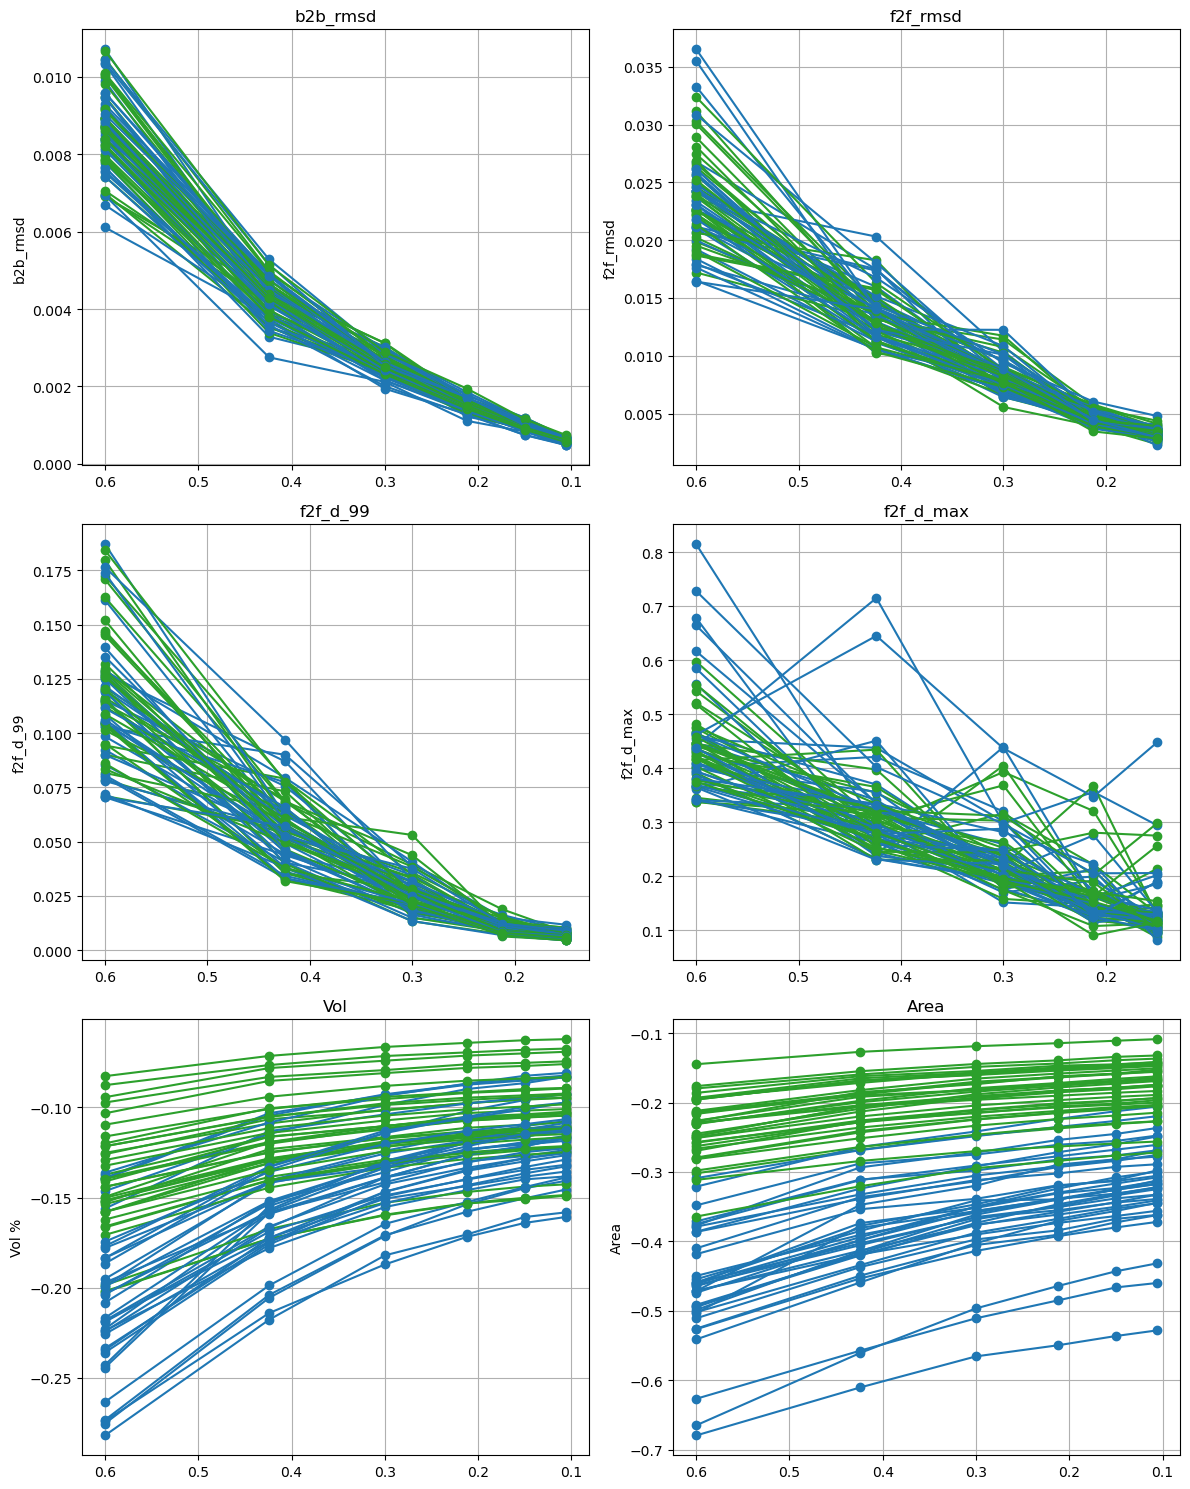

In [ ]:
# somtimes there are holes on edge of mesh - could affect area
# the f2f_d_max can be misleading because it is influenced by where the boundary of the surfaces happends to lie
    # - maybe better to compute the distance of fine2cartilage_cap and field2fine_cartilage_cap or something similar (then hstack and compute metrics)

# vol of mc1 changes less than tpm cos volume loss is likely dominated by sharpish feature loss
#  mc1 both bigger and has less sharpish features

import matplotlib.pyplot as plt

bones = ['tpm', 'mc1']
subs_sides = df['sub'].unique()
x = df['fel'].unique()

# plot
fig, ax = plt.subplots(3, 2, figsize=(12, 15))
ax = ax.flatten()

c_map = {
    'tpm': 'tab:blue',
    'mc1': 'tab:green'
}

for sub in subs_sides:
    #sub_df = df[(df['sub'] == sub) & (df['bone']==bone)]
    for bone in bones:
        sub_df = df[(df['sub'] == sub) & (df['bone']==bone)]
        c = c_map[bone]
    #x = sub_df['cells_field'][::-1]

        ax[0].plot(x, sub_df['b2b_rmsd'], marker='o', c=c)
        ax[0].set_title('b2b_rmsd')
        ax[0].set_ylabel('b2b_rmsd')

        ax[1].plot(x, sub_df['f2f_rmsd'], marker='o', c=c)
        ax[1].set_title('f2f_rmsd')
        ax[1].set_ylabel('f2f_rmsd')

        ax[2].plot(x, sub_df['f2f_d_99'], marker='o', c=c)
        ax[2].set_title('f2f_d_99')
        ax[2].set_ylabel('f2f_d_99')

        ax[3].plot(x, sub_df['f2f_d_max'] , marker='o', c=c)
        ax[3].set_title('f2f_d_max')
        ax[3].set_ylabel('f2f_d_max')

        ax[4].plot(x, 100* (sub_df['remesh_V'] - sub_df['smooth_V']) / sub_df['smooth_V'], marker='o', c=c)
        ax[4].set_title('Vol')
        ax[4].set_ylabel('Vol %')

        # area slowly increases as it squeezes out every point up to 2mm
        ax[5].plot(x, 100* (sub_df['remesh_A'] - sub_df['smooth_A']) / sub_df['smooth_A'], marker='o', c=c)
        ax[5].set_title('Area')
        ax[5].set_ylabel('Area')


for ax_i in ax:
    ax_i.grid()  
    ax_i.invert_xaxis()

plt.tight_layout()

### FEL = 0.2 gets f2f_99 below 0.02 mm and abs rate of change below 0.01 mm and runtime at ~10s per subject (10 mins for all for both 2Dmesh and cartilage)
 - % rate of decrease of f2f is pretty regular so kind of just have to choose an absolute value and go with it

#### plot absolute change in the above metrics

In [60]:
df.columns

Index(['sub', 'bone', 'fel', 'b2b_rmsd', 'f2b_rmsd', 'f2f_rmsd', 'f2f_d_mean',
       'f2f_d_median', 'f2f_d_std', 'f2f_d_max', 'f2f_d_99', 'f2f_d_95',
       'b2b_d_mean', 'b2b_d_median', 'b2b_d_std', 'b2b_d_max', 'b2b_d_99',
       'b2b_d_95', 'f2b_d_mean', 'f2b_d_median', 'f2b_d_std', 'f2b_d_max',
       'f2b_d_99', 'f2b_d_95', 'field_points', 'field_cells', 'field_A',
       'smooth_points', 'smooth_cells', 'smooth_A', 'smooth_V',
       'remesh_points', 'remesh_cells', 'remesh_A', 'remesh_V'],
      dtype='str')

In [79]:
# compute absolute and relative change between edge length steps

df = df.sort_values(["sub", "bone", "fel"], ascending=False).copy()
change = df.groupby(["sub", "bone"])[df.columns[2:]]

abs_change = change.diff().add_suffix("_abs")
rel_change = change.pct_change().add_suffix("_rel")

df_change = pd.concat(
    [df[["sub", "bone", "fel"]].reset_index(drop=True),
     abs_change.reset_index(drop=True),
     rel_change.reset_index(drop=True)],
    axis=1,
)

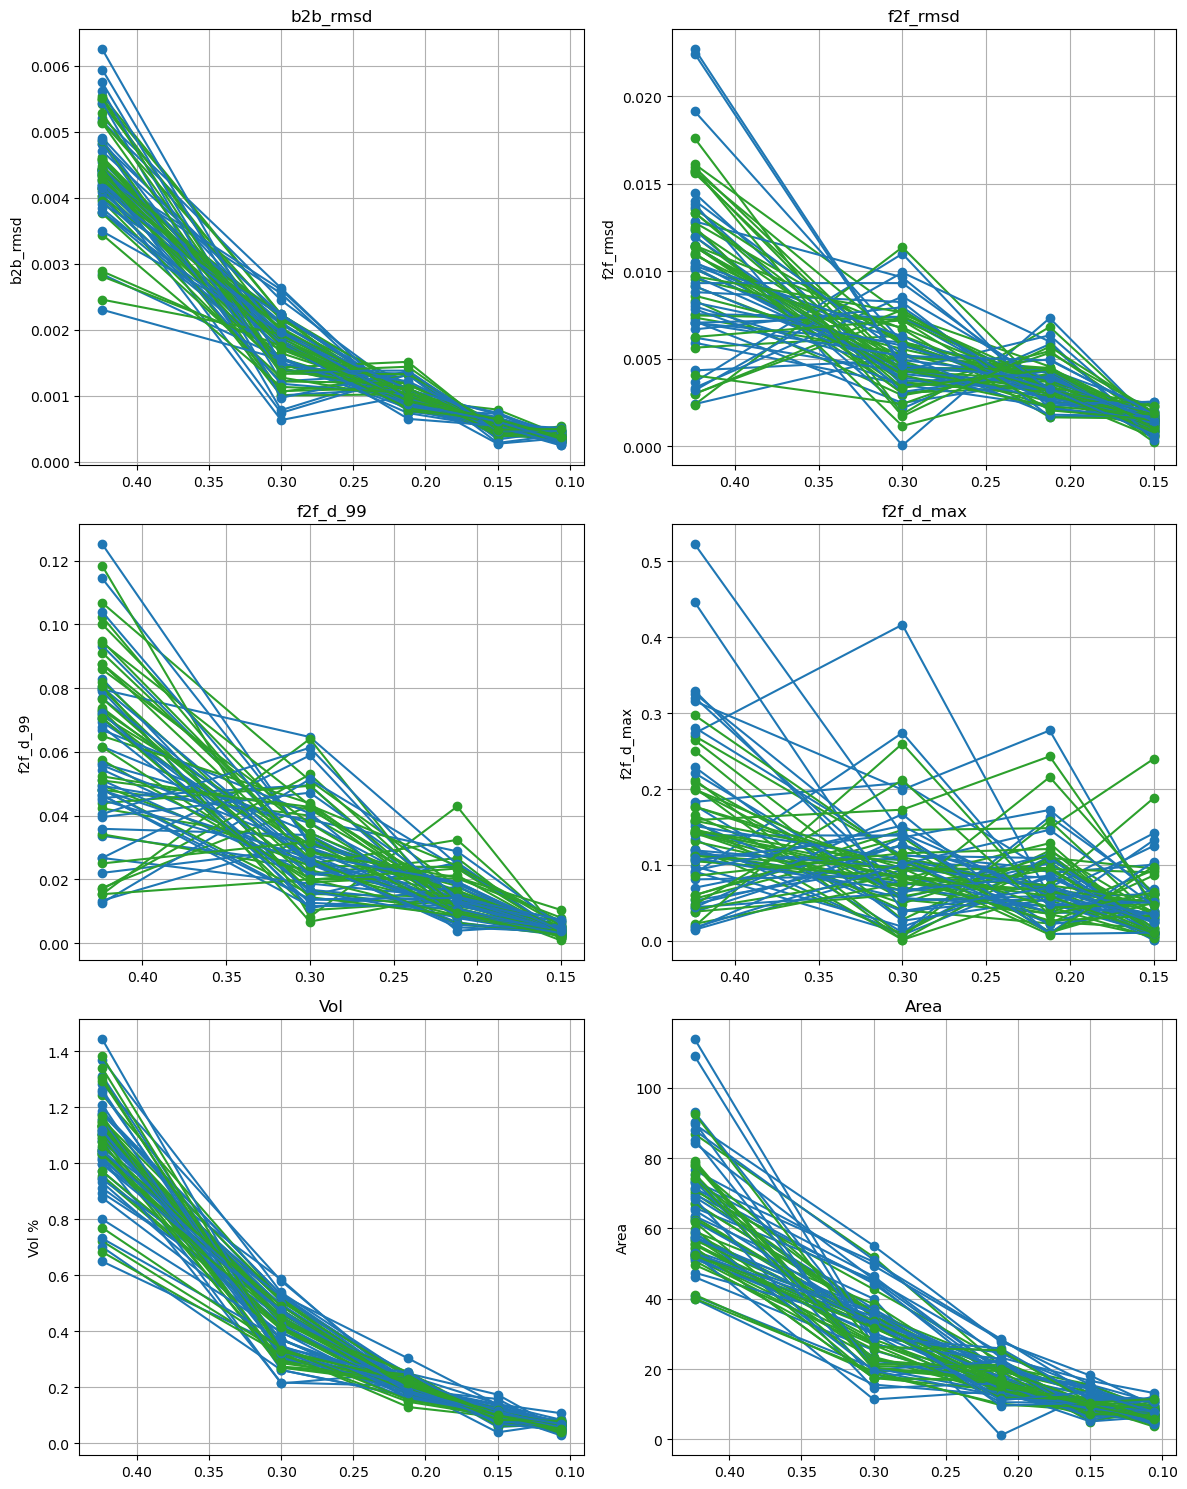

In [81]:
# somtimes there are holes on edge of mesh - could affect area
# the f2f_d_max can be misleading because it is influenced by where the boundary of the surfaces happends to lie
    # - maybe better to compute the distance of fine2cartilage_cap and field2fine_cartilage_cap or something similar (then hstack and compute metrics)

# vol of mc1 changes less than tpm cos volume loss is likely dominated by sharpish feature loss
#  mc1 both bigger and has less sharpish features

import matplotlib.pyplot as plt

select = 'abs'
bones = ['tpm', 'mc1']
subs_sides = df_change['sub'].unique()
x = df['fel'].unique()

# plot
fig, ax = plt.subplots(3, 2, figsize=(12, 15))
ax = ax.flatten()

c_map = {
    'tpm': 'tab:blue',
    'mc1': 'tab:green'
}

for sub in subs_sides:
    #sub_df = df[(df['sub'] == sub) & (df['bone']==bone)]
    for bone in bones:
        sub_df = df_change[(df_change['sub'] == sub) & (df_change['bone']==bone)]
        c = c_map[bone]
    #x = sub_df['cells_field'][::-1]

        ax[0].plot(x, sub_df[f'b2b_rmsd_{select}'].abs(), marker='o', c=c)
        ax[0].set_title('b2b_rmsd')
        ax[0].set_ylabel('b2b_rmsd')

        ax[1].plot(x, sub_df[f'f2f_rmsd_{select}'].abs(), marker='o', c=c)
        ax[1].set_title('f2f_rmsd')
        ax[1].set_ylabel('f2f_rmsd')

        ax[2].plot(x, sub_df[f'f2f_d_99_{select}'].abs(), marker='o', c=c)
        ax[2].set_title('f2f_d_99')
        ax[2].set_ylabel('f2f_d_99')

        ax[3].plot(x, sub_df[f'f2f_d_max_{select}'].abs() , marker='o', c=c)
        ax[3].set_title('f2f_d_max')
        ax[3].set_ylabel('f2f_d_max')

        ax[4].plot(x, sub_df[f'remesh_V_{select}'].abs(), marker='o', c=c)
        ax[4].set_title('Vol')
        ax[4].set_ylabel('Vol %')

        # area slowly increases as it squeezes out every point up to 2mm
        ax[5].plot(x, 100* sub_df[f'remesh_A_{select}'].abs(), marker='o', c=c)
        ax[5].set_title('Area')
        ax[5].set_ylabel('Area')


for ax_i in ax:
    ax_i.grid()  
    ax_i.invert_xaxis()

plt.tight_layout()

### FEL = 0.2 keeps absolute change for f2f below 0.01mm

### Runtime

In [22]:
runtime_file = 'outputs-redo/height_field/reports/runtimes.jsonl'
runtimes = pd.read_json(runtime_file, lines=True)

param_file0 = "full_params.json" # all 2d meshes and tpm cartilage 
param_file1 = "full_params-1.json" # mc1 cartilage

In [43]:
runtimes_2d = runtimes[(runtimes['step']=='2Dmesh') & (runtimes['full_params']==param_file0)][['subject', 'runtime']].reset_index(drop=True).copy()
runtimes_cart = runtimes[runtimes['step']=='cartilage'][['subject', 'runtime', 'bones']].reset_index(drop=True).copy()

print('All 2Dmesh runtimes:', (runtimes_2d['subject'].value_counts() == 6).all())
print('All cartilage runtimes:', (runtimes_cart['subject'].value_counts() == 12).all())

All 2Dmesh runtimes: True
All cartilage runtimes: True


In [ ]:
# add edge lengths to df
fels = [0.6, 0.424, 0.3, 0.212, 0.15, 0.106]
runtimes_cart['fel'] = np.tile(fels, len(runtimes_cart.subject.unique()) * 2)

#### Interference mask (no errors)
 - mask of subjects that had successful cartilage run for both the tpm and mc1 for the given fine edge length

In [56]:
inter_file = 'outputs-redo/height_field/reports/interference.jsonl'
inters = pd.read_json(inter_file, lines=True)

# mask of subjects that had successful run for both the tpm and mc1 for the given fine edge length
mask = np.ones(len(runtimes_cart), dtype=bool)
for i in range(len(inters)):
    row = inters.iloc[i]
    sub = row['subject']
    bn = row['bones']
    run_id = int(row['run_ids'][0])

    cart_id = runtimes_cart[(runtimes_cart['subject']==sub)&(runtimes_cart['bones']==bn)].iloc[run_id].name
    mask[cart_id] = False
    # set pair to false cos later plot sum of their runtimes
    other_bn = bn.split('-')[1] + '-' + bn.split('-')[0] 
    cart_id2 = runtimes_cart[(runtimes_cart['subject']==sub)&(runtimes_cart['bones']==other_bn)].iloc[run_id].name
    mask[cart_id2] = False

# df of all runs with no errors or interference
runtimes_cart_ok = runtimes_cart[mask].copy()
print(len(runtimes_cart_ok.subject.unique())) # all subjects have at least one successfull run

36


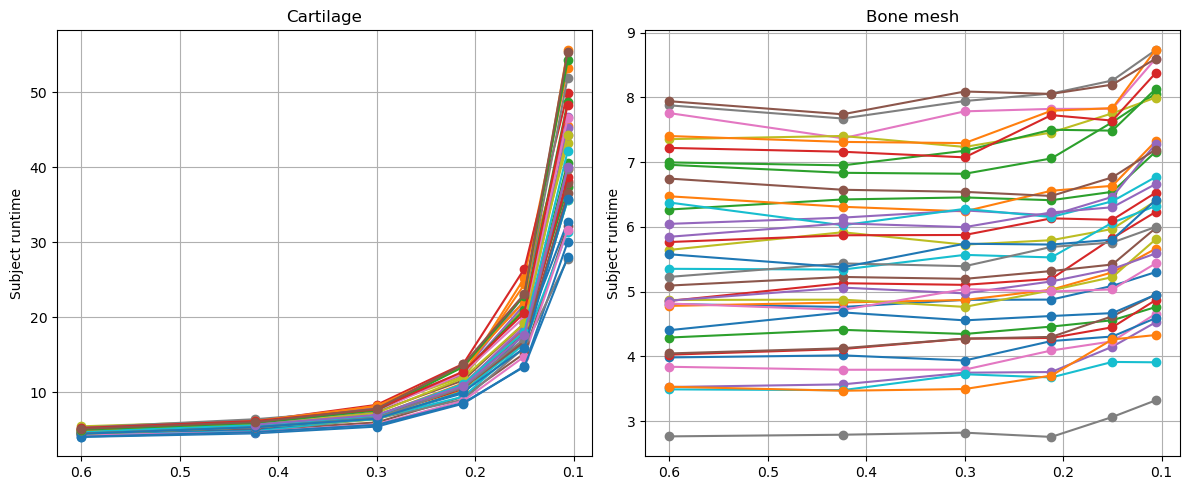

In [58]:
fels = [0.6, 0.424, 0.3, 0.212, 0.15, 0.106]
import matplotlib.pyplot as plt

subs_sides = runtimes_cart_ok.subject.unique()

# plot
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax = ax.flatten()

for sub in subs_sides:

    # cartilage 
    sub_df = runtimes_cart_ok[runtimes_cart_ok['subject'] == sub]
    y = sub_df[sub_df['bones']=='tpm-mc1']['runtime'].values + sub_df[sub_df['bones']=='mc1-tpm']['runtime'].values
    x = sub_df[sub_df['bones']=='tpm-mc1']['fel']

    ax[0].plot(x, y, marker='o')
    ax[0].set_title('Cartilage')
    ax[0].set_ylabel('Edge length')
    ax[0].set_ylabel('Subject runtime')

    # 2Dmesh
    sub_df = runtimes_2d[runtimes_2d['subject'] == sub]
    y = sub_df['runtime']
    x = fels
    
    ax[1].plot(x, y, marker='o')
    ax[1].set_title('Bone mesh')
    ax[1].set_ylabel('Edge length')
    ax[1].set_ylabel('Subject runtime')


for ax_i in ax:
    ax_i.grid()  
    ax_i.invert_xaxis()

plt.tight_layout()

### FEL = 0.2 keeps average runtime at about 10s per subejct (only around 2-3s more than 0.3) for cartilage and 5s for 2Dmesh

# Isotropic remeshing iterations
 - to ensure not changing important mesh geometry
 - [1, 5, 10, 20, 40, 80]

In [82]:
import subprocess
path_MeshPipeline_main = '../../../../MeshPipeline/main.py'
subprocess.run(["python", path_MeshPipeline_main])


Updating parameters.json
	Wrote /Users/maro/Library/CloudStorage/OneDrive-UniversityofLeeds/PhD-wrist/WorkPackages/WorkPackages/TMCJ-Contact/Computational/MeshPipeline/set_parameters/parameters.json


Full parameter file saved to outputs-redo/iterations/params/full_params.json

SUBJECT: 14548R
	BONES: mc1-tpm
		STEP: 2Dmesh
			RUN ID: -0
			Runtime: 4.856s - ok
			RUN ID: -1
			Runtime: 5.006s - ok
			RUN ID: -2
			Runtime: 5.330s - ok
			RUN ID: -3
			Runtime: 5.741s - ok
			RUN ID: -4
			Runtime: 6.365s - ok
			RUN ID: -5
			Runtime: 8.173s - ok

SUBJECT: 14613R
	BONES: mc1-tpm
		STEP: 2Dmesh
			RUN ID: -0
			Runtime: 5.290s - ok
			RUN ID: -1
			Runtime: 5.387s - ok
			RUN ID: -2
			Runtime: 6.132s - ok
			RUN ID: -3
			Runtime: 6.350s - ok
			RUN ID: -4
			Runtime: 7.540s - ok
			RUN ID: -5
			Runtime: 9.635s - ok

SUBJECT: 14685R
	BONES: mc1-tpm
		STEP: 2Dmesh
			RUN ID: -0
			Runtime: 6.102s - ok
			RUN ID: -1
			Runtime: 6.281s - ok
			RUN ID: -2
			Runtime: 6.494s - ok
			RUN 

CompletedProcess(args=['python', '../../../../MeshPipeline/main.py'], returncode=0)

In [ ]:
output_root = Path('outputs-redo/iterations')
bone_arbone = 'tpm-mc1'
subject_sideL = '14548R'
run_id = '-3'

bone_remesh = pv.read(f'{output_root}/meshes/{subject_sideL}/{bone_arbone}/2Dmesh/bone_remesh{run_id}.obj')

In [ ]:
n_samples = 20000

iters = [1, 5, 10, 20, 40, 80]

path = Path('outputs-redo/iterations/meshes')

subs_sides = [p.name for p in path.iterdir() if p.is_dir()]
bone_pairs = ['tpm-mc1', 'mc1-tpm']
poses = ['adduction','abduction','flexion','extension','pinch','grasp','jar','neutral']

data = []
for sub in tqdm(subs_sides):
    subject, sideL = sub[:-1], sub[-1]
    stl_path = get_subject_stl_path(subject, sideL)
    for bone_pair in bone_pairs:
        bone, arbone = bone_pair.split('-')

        # get interface region of smooth mesh
        smooth = get_mesh(stl_path, bone).smooth_taubin(n_iter=50)
        smooth_ar = get_mesh(stl_path, arbone).smooth_taubin(n_iter=50)
        min_df = get_min_df_fast(stl_path, bone, arbone, smooth, smooth_ar, poses, 2)
        smooth_inter = smooth.extract_points(min_df['bone_id'], adjacent_cells=False).extract_surface(algorithm=None)

        for i in range(len(iters)):
            remesh = pv.read(path / f'{sub}/{bone_pair}/2Dmesh/bone_remesh-{i}.obj')
            remesh_ar = pv.read(path / f'{sub}/{arbone}-{bone}/2Dmesh/bone_remesh-{i}.obj')
            min_df = get_min_df_fast(stl_path, bone, arbone, remesh, remesh_ar, poses, 2)
            remesh_inter = remesh.extract_points(min_df['bone_id'], adjacent_cells=False).extract_surface(algorithm=None)

            s2r = compute_dists(sample_surface(smooth_inter, n_samples), remesh)
            r2s = compute_dists(sample_surface(remesh_inter, n_samples), smooth)
            d = np.hstack( (s2r, r2s) )


            mets = {
                'sub': sub,
                'bone': bone,
                'iters': iters[i],
                'rmsd': compute_rmsd(d)
            }
            # distance
            mets = compute_d_metrics(d, mets, 'd_')
            # surface
            mets = compute_mesh_metrics(smooth, mets, vol=True, edge_length=False, label='smooth_')
            mets = compute_mesh_metrics(remesh, mets, vol=True, edge_length=False, label='remesh_')

            data.append(mets)
#pd.DataFrame(data).to_csv('outputs-redo/iterations_metrics.csv', index=False)

100%|██████████| 36/36 [22:47<00:00, 37.98s/it]


#### Edge lengths aswell

In [104]:
from phd_helpers.paths import compute_edge_lengths

n_samples = 20000

iters = [1, 5, 10, 20, 40, 80]

path = Path('outputs-redo/iterations/meshes')

subs_sides = [p.name for p in path.iterdir() if p.is_dir()]
bone_pairs = ['tpm-mc1', 'mc1-tpm']
poses = ['adduction','abduction','flexion','extension','pinch','grasp','jar','neutral']

data = []
for sub in tqdm(subs_sides):
    subject, sideL = sub[:-1], sub[-1]
    stl_path = get_subject_stl_path(subject, sideL)
    for bone_pair in bone_pairs:
        bone, arbone = bone_pair.split('-')

        for i in range(len(iters)):
            remesh = pv.read(path / f'{sub}/{bone_pair}/2Dmesh/bone_remesh-{i}.obj')
            remesh_ar = pv.read(path / f'{sub}/{arbone}-{bone}/2Dmesh/bone_remesh-{i}.obj')
            min_df = get_min_df_fast(stl_path, bone, arbone, remesh, remesh_ar, poses, 2)
            remesh_inter = remesh.extract_points(min_df['bone_id'], adjacent_cells=False).extract_surface(algorithm=None)

            mets = {
                'sub': sub,
                'bone': bone,
                'iters': iters[i]
            }
            # edge length
            mets = compute_d_metrics(compute_edge_lengths(remesh_inter), mets, 'L_edge_')

            data.append(mets)
pd.DataFrame(data).to_csv('outputs-redo/iterations_metrics_Ledge.csv', index=False)

100%|██████████| 36/36 [20:38<00:00, 34.39s/it]


In [105]:
df_edge = pd.read_csv('outputs-redo/iterations_metrics_Ledge.csv')
df_edge

,sub,bone,iters,L_edge_mean,L_edge_median,L_edge_std,L_edge_max,L_edge_99,L_edge_95
0,14818R,tpm,1,0.176590,0.173653,0.025914,0.292033,0.242838,0.221952
1,14818R,tpm,5,0.178366,0.176453,0.020553,0.253473,0.228464,0.214066
2,14818R,tpm,10,0.178628,0.176817,0.019433,0.249110,0.227126,0.212311
3,14818R,tpm,20,0.178728,0.176945,0.018766,0.249737,0.226297,0.211126
4,14818R,tpm,40,0.178993,0.177560,0.018356,0.252556,0.225705,0.210504
...,...,...,...,...,...,...,...,...,...
427,15283R,mc1,5,0.188858,0.187168,0.024553,0.281180,0.246124,0.232854
428,15283R,mc1,10,0.188727,0.187307,0.023475,0.269861,0.243795,0.230430
429,15283R,mc1,20,0.188793,0.187670,0.022684,0.275628,0.242425,0.228823
430,15283R,mc1,40,0.188858,0.187875,0.022253,0.264811,0.242269,0.228023


In [100]:
df = pd.read_csv('outputs-redo/iterations_metrics.csv')
df

,sub,bone,iters,rmsd,d_mean,d_median,d_std,d_max,d_99,d_95,smooth_points,smooth_cells,smooth_A,smooth_V,remesh_points,remesh_cells,remesh_A,remesh_V
0,14818R,tpm,1,0.001289,0.000647,0.000250,0.001115,0.019405,0.005527,0.002677,9398,18792,822.792303,1747.154425,11434,22864,820.111956,1744.770991
1,14818R,tpm,5,0.001478,0.000787,0.000330,0.001251,0.016068,0.006296,0.003123,9398,18792,822.792303,1747.154425,11051,22098,819.931327,1744.628447
2,14818R,tpm,10,0.001531,0.000840,0.000375,0.001280,0.018698,0.006380,0.003323,9398,18792,822.792303,1747.154425,11016,22028,819.870234,1744.581947
3,14818R,tpm,20,0.001610,0.000891,0.000409,0.001340,0.018724,0.006777,0.003466,9398,18792,822.792303,1747.154425,10999,21994,819.786588,1744.519098
4,14818R,tpm,40,0.001703,0.000952,0.000440,0.001412,0.019207,0.006945,0.003727,9398,18792,822.792303,1747.154425,10993,21982,819.694211,1744.436753
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
427,15283R,mc1,5,0.001393,0.000732,0.000322,0.001184,0.017973,0.006063,0.002852,12480,24956,2313.577957,6468.402165,18987,37970,2310.937823,6463.924056
428,15283R,mc1,10,0.001547,0.000805,0.000352,0.001321,0.018297,0.006735,0.003088,12480,24956,2313.577957,6468.402165,18958,37912,2310.728425,6463.481516
429,15283R,mc1,20,0.001639,0.000855,0.000363,0.001399,0.024172,0.007004,0.003388,12480,24956,2313.577957,6468.402165,18926,37848,2310.493345,6463.005240
430,15283R,mc1,40,0.001739,0.000912,0.000382,0.001480,0.023334,0.007385,0.003658,12480,24956,2313.577957,6468.402165,18910,37816,2310.297792,6462.607458


In [108]:
df = pd.merge(df_edge, df)
df

,sub,bone,iters,L_edge_mean,L_edge_median,L_edge_std,L_edge_max,L_edge_99,L_edge_95,rmsd,...,d_99,d_95,smooth_points,smooth_cells,smooth_A,smooth_V,remesh_points,remesh_cells,remesh_A,remesh_V
0,14818R,tpm,1,0.176590,0.173653,0.025914,0.292033,0.242838,0.221952,0.001289,...,0.005527,0.002677,9398,18792,822.792303,1747.154425,11434,22864,820.111956,1744.770991
1,14818R,tpm,5,0.178366,0.176453,0.020553,0.253473,0.228464,0.214066,0.001478,...,0.006296,0.003123,9398,18792,822.792303,1747.154425,11051,22098,819.931327,1744.628447
2,14818R,tpm,10,0.178628,0.176817,0.019433,0.249110,0.227126,0.212311,0.001531,...,0.006380,0.003323,9398,18792,822.792303,1747.154425,11016,22028,819.870234,1744.581947
3,14818R,tpm,20,0.178728,0.176945,0.018766,0.249737,0.226297,0.211126,0.001610,...,0.006777,0.003466,9398,18792,822.792303,1747.154425,10999,21994,819.786588,1744.519098
4,14818R,tpm,40,0.178993,0.177560,0.018356,0.252556,0.225705,0.210504,0.001703,...,0.006945,0.003727,9398,18792,822.792303,1747.154425,10993,21982,819.694211,1744.436753
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
427,15283R,mc1,5,0.188858,0.187168,0.024553,0.281180,0.246124,0.232854,0.001393,...,0.006063,0.002852,12480,24956,2313.577957,6468.402165,18987,37970,2310.937823,6463.924056
428,15283R,mc1,10,0.188727,0.187307,0.023475,0.269861,0.243795,0.230430,0.001547,...,0.006735,0.003088,12480,24956,2313.577957,6468.402165,18958,37912,2310.728425,6463.481516
429,15283R,mc1,20,0.188793,0.187670,0.022684,0.275628,0.242425,0.228823,0.001639,...,0.007004,0.003388,12480,24956,2313.577957,6468.402165,18926,37848,2310.493345,6463.005240
430,15283R,mc1,40,0.188858,0.187875,0.022253,0.264811,0.242269,0.228023,0.001739,...,0.007385,0.003658,12480,24956,2313.577957,6468.402165,18910,37816,2310.297792,6462.607458


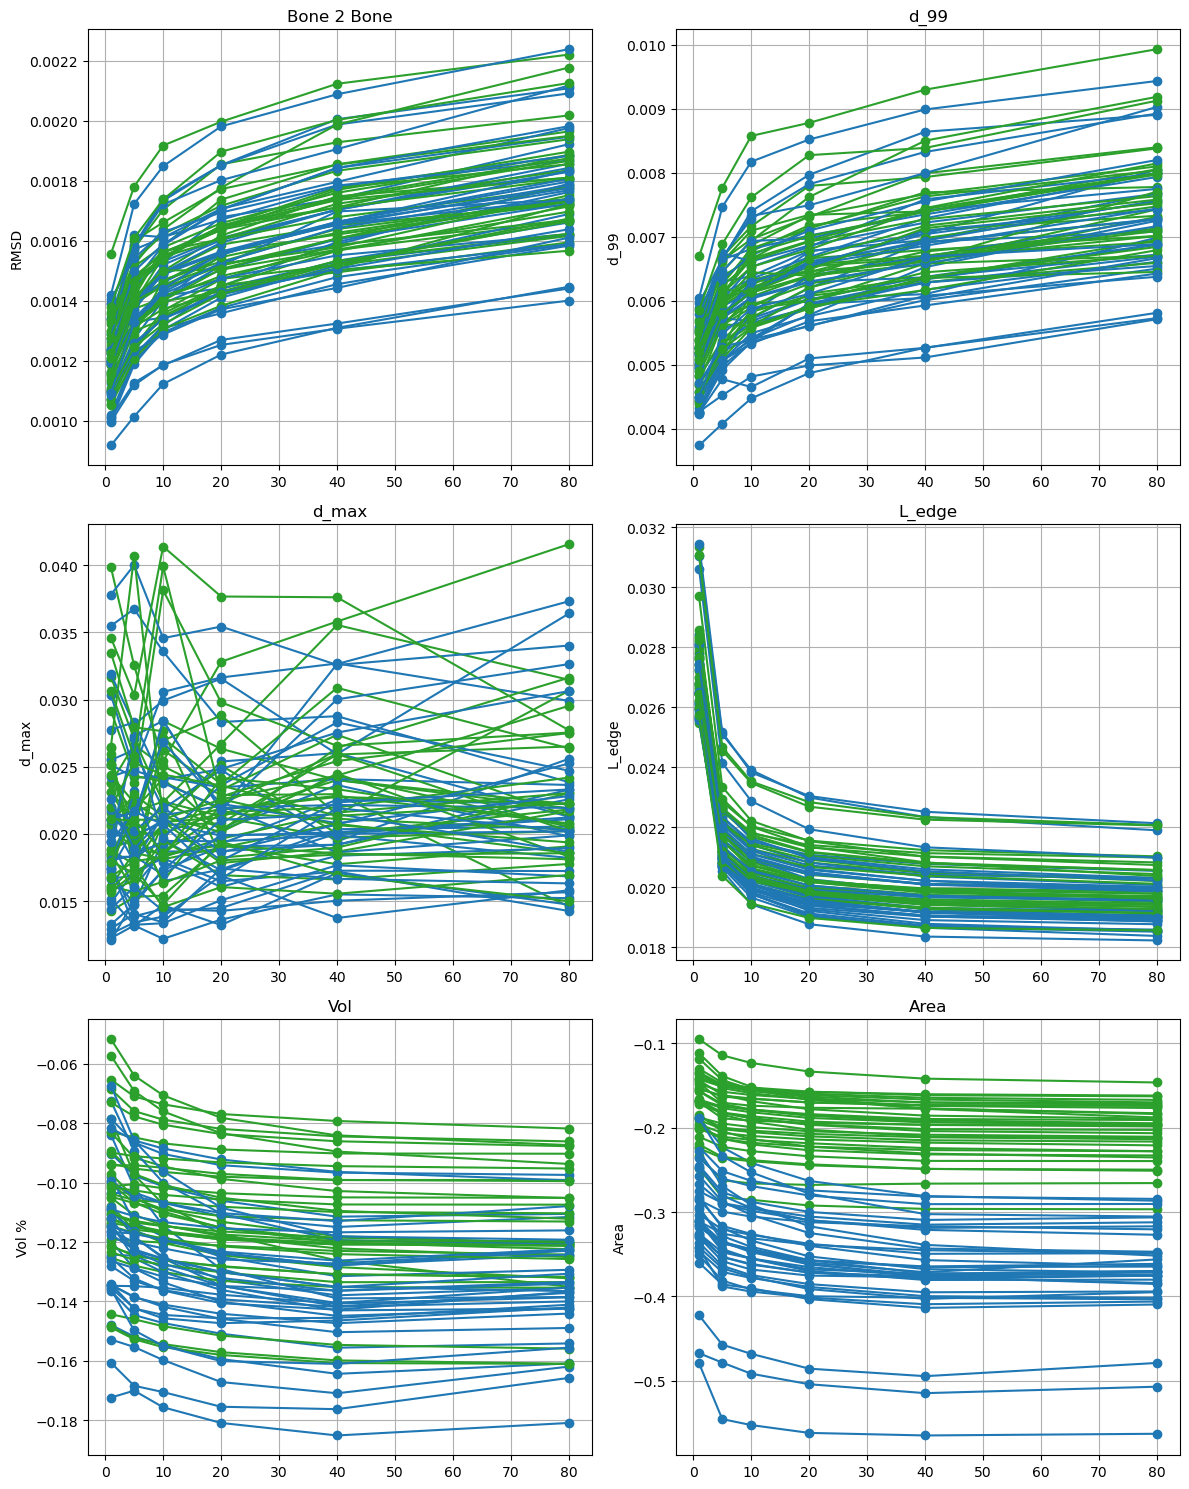

In [110]:
# somtimes there are holes on edge of mesh where a cell should be or was in previous mesh
# max distance field 2 field can be affected by one point lying in one of the empty channels that form in the field

import matplotlib.pyplot as plt

bones = ['tpm', 'mc1']
subs_sides = df['sub'].unique()
x = df['iters'].unique()

# plot
fig, ax = plt.subplots(3, 2, figsize=(12, 15))
ax = ax.flatten()

c_map = {
    'tpm': 'tab:blue',
    'mc1': 'tab:green'
}

for sub in subs_sides:
    #sub_df = df[(df['sub'] == sub) & (df['bone']==bone)]
    for bone in bones:
        sub_df = df[(df['sub'] == sub) & (df['bone']==bone)]
        c = c_map[bone]
    #x = sub_df['cells_field'][::-1]

        ax[0].plot(x, sub_df['rmsd'], marker='o', c=c)
        ax[0].set_title('Bone 2 Bone')
        ax[0].set_ylabel('RMSD')

        ax[1].plot(x, sub_df['d_99'], marker='o', c=c)
        ax[1].set_title('d_99')
        ax[1].set_ylabel('d_99')

        ax[2].plot(x, sub_df['d_max'], marker='o', c=c)
        ax[2].set_title('d_max')
        ax[2].set_ylabel('d_max')

        ax[3].plot(x, sub_df['L_edge_std'], marker='o', c=c)
        ax[3].set_title('L_edge')
        ax[3].set_ylabel('L_edge')

        ax[4].plot(x, 100* (sub_df['remesh_V'] - sub_df['smooth_V']) / sub_df['smooth_V'], marker='o', c=c)
        ax[4].set_title('Vol')
        ax[4].set_ylabel('Vol %')

        # area slowly increases as it squeezes out every point up to 2mm
        ax[5].plot(x, 100* (sub_df['remesh_A'] - sub_df['smooth_A']) / sub_df['smooth_A'], marker='o', c=c)
        ax[5].set_title('Area')
        ax[5].set_ylabel('Area')


for ax_i in ax:
    ax_i.grid()  

plt.tight_layout()

### the fact is is almost identical to smooth mesh surface means that the choice to remesh to save computation time for cartilage step is valid!!!!
### choose 5 cos of runtime, edge length std abs / rate of change, and avoiding more unnecesary volume loss

#### runtime

In [102]:
iters = [1, 5, 10, 20, 40, 80]

run_df = pd.read_json('outputs-redo/iterations/reports/runtimes.jsonl', lines=True)
subs_sides = run_df['subject'].unique()
print(len(subs_sides), 'subjects')

run_df['iters'] = np.tile(iters, len(subs_sides))

36 subjects


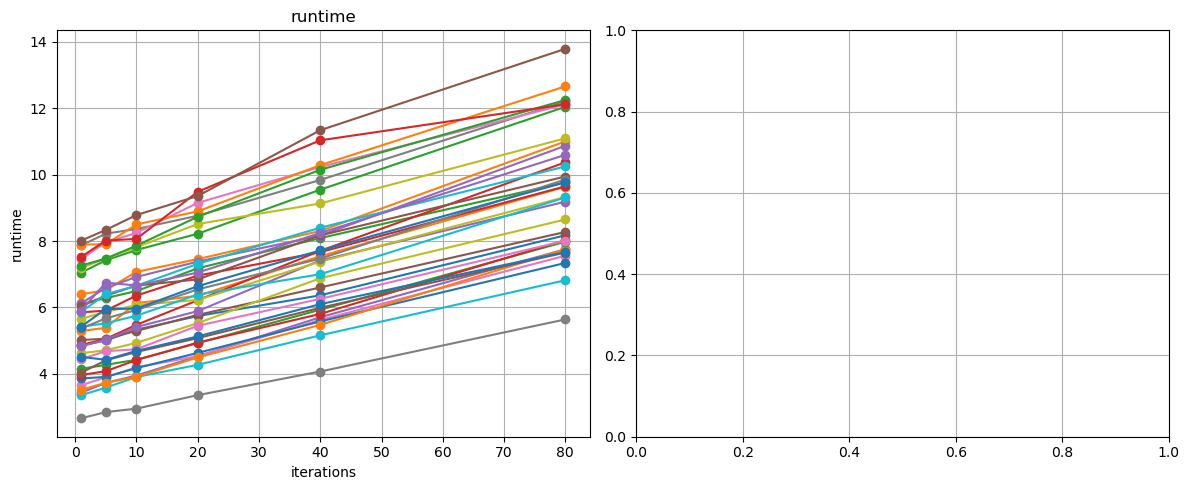

In [103]:
# plot
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax = ax.flatten()

for sub in subs_sides:
    sub_df = run_df[run_df['subject'] == sub]

    ax[0].plot(iters, sub_df['runtime'], marker='o')
    ax[0].set_title('runtime')
    ax[0].set_xlabel('iterations')
    ax[0].set_ylabel('runtime')


for ax_i in ax:
    ax_i.grid()  

plt.tight_layout()